In [1]:
import os

# Ensure relative paths resolve from the snapViT project directory.
os.chdir("/home/ale_navone/ws_pytorch/GAIA/snapViT")

# ============================================================
# CONFIGURATION — edit this cell to add / remove model runs.
# Each entry needs:
#   "folder" : path to the evaluation folder containing
#              cosine_per_scene.csv  (relative to snapViT/ or
#              absolute)
#   "name"   : human-readable label shown in plot titles
# ============================================================
model_configs = [
    #{
    #    "folder": "evaluation/rete_consecutiva",
    #    "name": "Consecutive Frames Training",
    #},
    #{
    #    "folder": "evaluation/rete_random",
    #    "name": "Random Frames Training",
    #},

    {
        "folder": "evaluation/rete_random_test",
        "name": "Pixel Loss",
    },
    {
        "folder": "evaluation/rete_consecutive_global_loss",
        "name": "Global Loss",
    },
    {
        "folder": "evaluation/random_frames_mixed_loss_lambda_0_5_1",
        "name": "Weighted Loss (λ=0.5)",
    }
    

    
    # Example: add more models here
    # {
    #     "folder": "evaluation/my_new_model",
    #     "name": "My New Model",
    # },
]


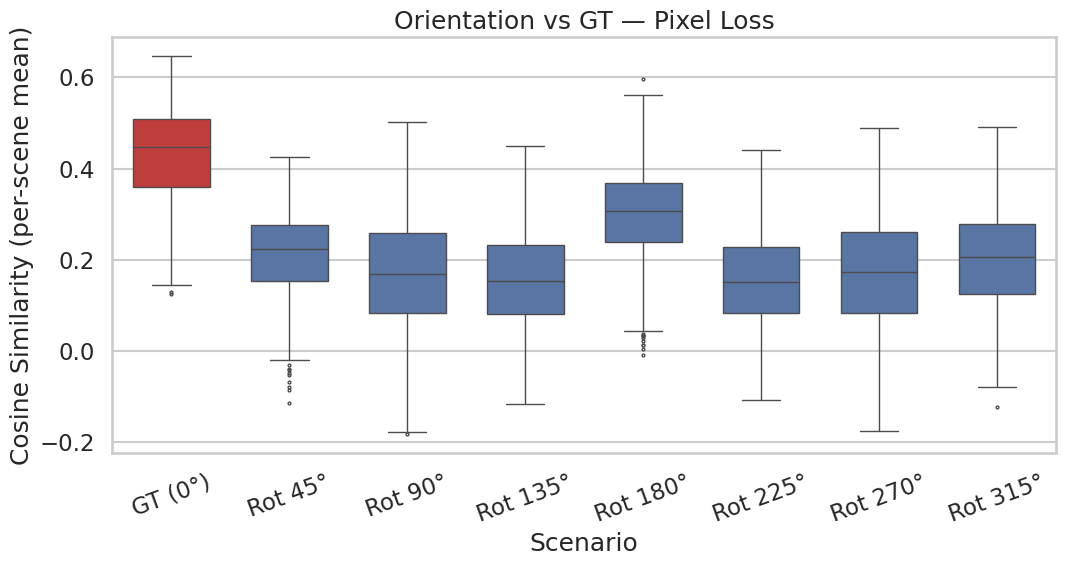

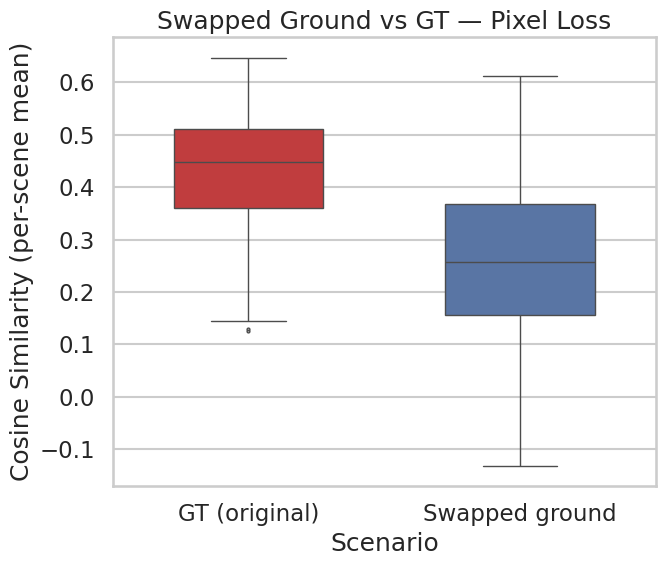

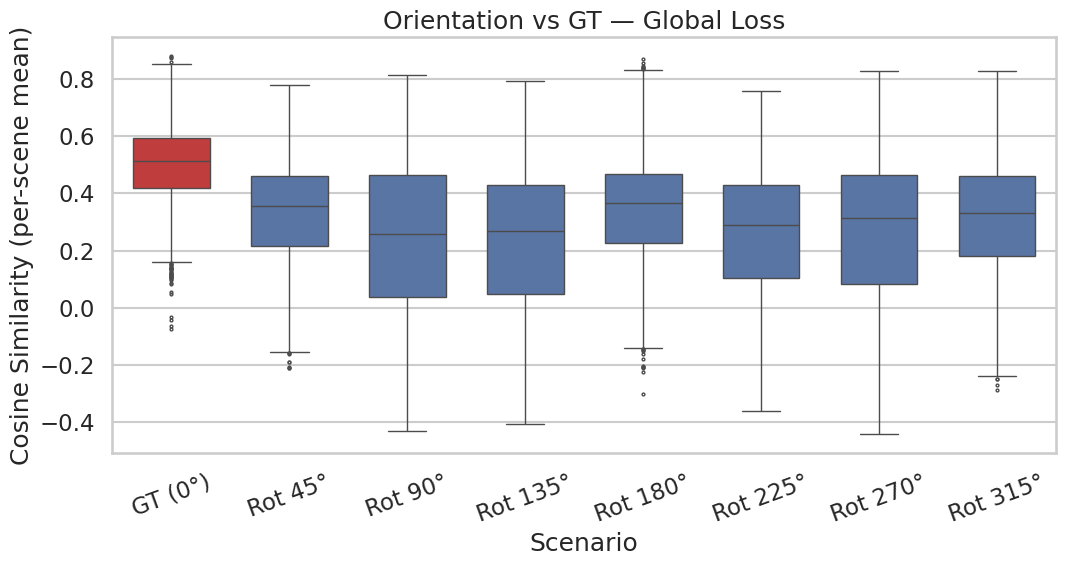

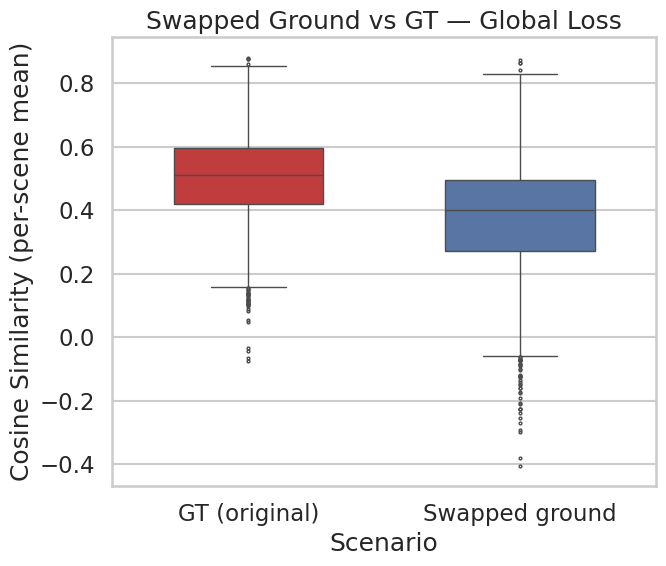

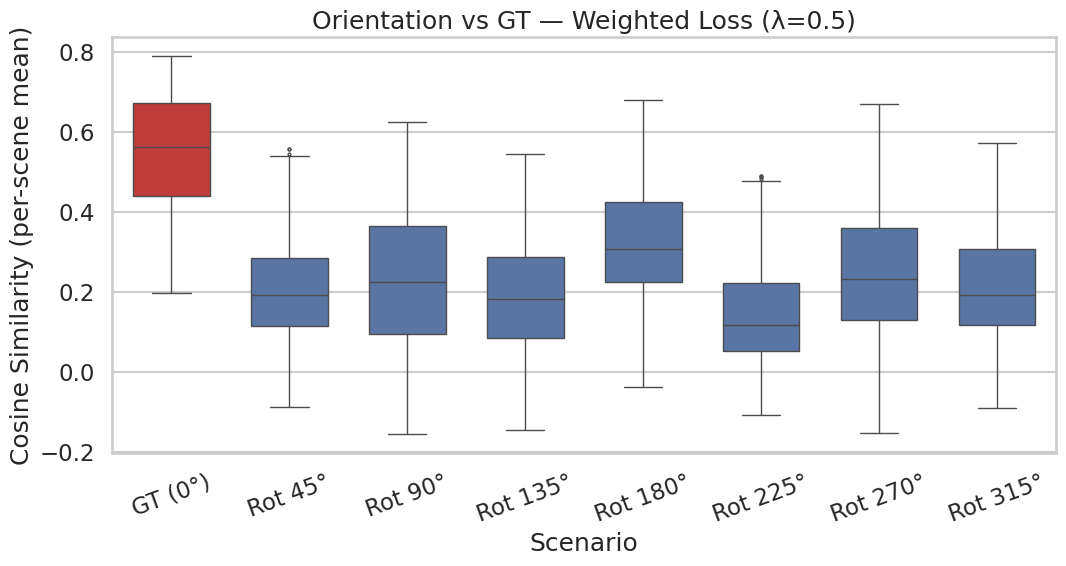

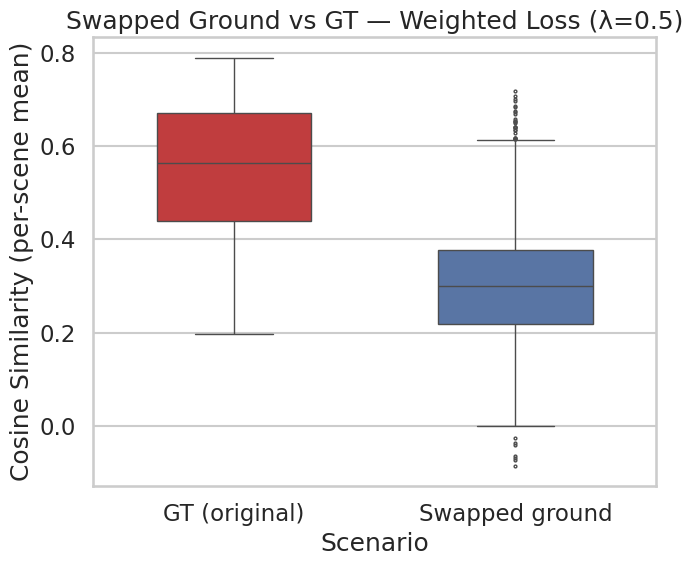

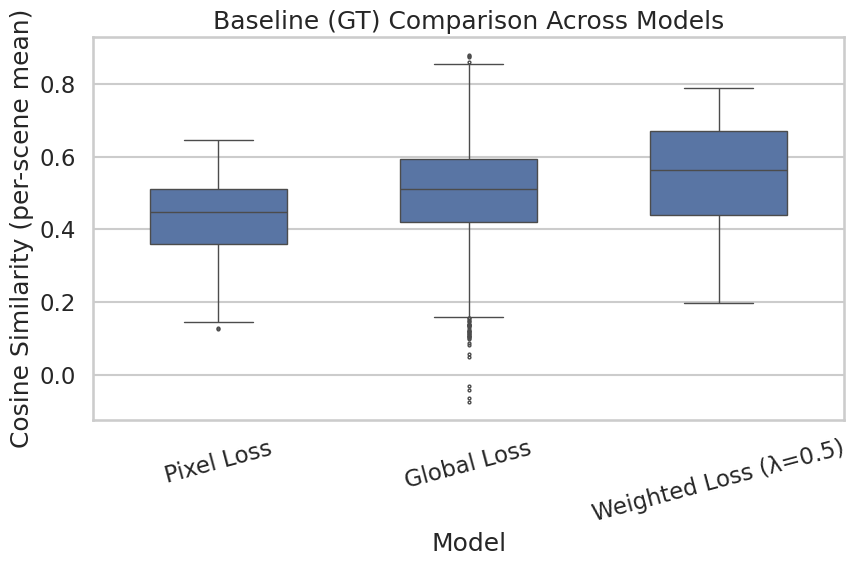

In [8]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ----- Scenario definitions -----
ORIENTATION_ORDER = [
    "baseline",
    "ground_rot_45",
    "ground_rot_90",
    "ground_rot_135",
    "ground_rot_180",
    "ground_rot_225",
    "ground_rot_270",
    "ground_rot_315",
]
ORIENTATION_LABELS = {
    "baseline": "GT (0°)",
    "ground_rot_45": "Rot 45°",
    "ground_rot_90": "Rot 90°",
    "ground_rot_135": "Rot 135°",
    "ground_rot_180": "Rot 180°",
    "ground_rot_225": "Rot 225°",
    "ground_rot_270": "Rot 270°",
    "ground_rot_315": "Rot 315°",
}

# Only baseline vs pure swap (no rotated+swapped variants).
SWAPPED_ORDER = ["baseline", "ground_swap"]
SWAPPED_LABELS = {
    "baseline": "GT (original)",
    "ground_swap": "Swapped ground",
}

GT_COLOR     = "#d62728"   # red  — ground truth
ALT_COLOR    = "#4c72b0"   # blue — other scenarios
MODEL_COLOR1 = "#4c72b0"   # blue — first half of models
MODEL_COLOR2 = "#dd8452"   # orange — second half of models

sns.set_theme(style="whitegrid", context="talk")

# Save all plots as PDF in graph_outputs/
out_dir = Path("graph_outputs")
out_dir.mkdir(parents=True, exist_ok=True)


def slugify(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", name.strip().lower()).strip("_") or "model"


# Collect baseline rows from each model for the cross-model comparison.
baseline_frames = []

# ----- Loop over model configs -----
for cfg in model_configs:
    folder = Path(cfg["folder"])
    name   = cfg["name"]
    name_slug = slugify(name)

    csv_path = folder / "cosine_per_scene.csv"
    if not csv_path.exists():
        print(f"[SKIP] {csv_path} not found — skipping '{name}'.")
        continue

    df = pd.read_csv(csv_path)
    # Exclude scenes with no valid pixels.
    df = df[df["valid_pixels"] > 0].copy()

    # ---------- Plot 1: Orientation vs GT ----------
    orient_df = df[df["scenario"].isin(ORIENTATION_ORDER)].copy()
    orient_df["label"] = orient_df["scenario"].map(ORIENTATION_LABELS)
    ordered_orient = [ORIENTATION_LABELS[s] for s in ORIENTATION_ORDER if ORIENTATION_LABELS[s] in orient_df["label"].values]
    palette_orient = {ORIENTATION_LABELS["baseline"]: GT_COLOR}
    palette_orient.update({ORIENTATION_LABELS[s]: ALT_COLOR for s in ORIENTATION_ORDER[1:]})

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.boxplot(
        data=orient_df,
        x="label",
        y="mean",
        hue="label",
        order=ordered_orient,
        hue_order=ordered_orient,
        palette=palette_orient,
        width=0.65,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Orientation vs GT — {name}")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    fig.savefig(out_dir / f"{name_slug}_orientation_vs_gt.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # ---------- Plot 2: Swapped ground vs GT ----------
    swapped_df = df[df["scenario"].isin(SWAPPED_ORDER)].copy()
    swapped_df["label"] = swapped_df["scenario"].map(SWAPPED_LABELS)
    ordered_swapped = [SWAPPED_LABELS[s] for s in SWAPPED_ORDER]
    palette_swapped = {SWAPPED_LABELS["baseline"]: GT_COLOR, SWAPPED_LABELS["ground_swap"]: ALT_COLOR}

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.boxplot(
        data=swapped_df,
        x="label",
        y="mean",
        hue="label",
        order=ordered_swapped,
        hue_order=ordered_swapped,
        palette=palette_swapped,
        width=0.55,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Swapped Ground vs GT — {name}")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    plt.tight_layout()
    fig.savefig(out_dir / f"{name_slug}_swapped_vs_gt.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Accumulate baseline rows for cross-model comparison.
    base_rows = df[df["scenario"] == "baseline"].copy()
    base_rows["model"] = name
    baseline_frames.append(base_rows)

# ---------- Plot 3: Baseline comparison across models ----------
if len(baseline_frames) >= 2:
    baseline_all = pd.concat(baseline_frames, ignore_index=True)
    model_names  = [cfg["name"] for cfg in model_configs if (Path(cfg["folder"]) / "cosine_per_scene.csv").exists()]

    half = len(model_names) // 2
    palette_models = {
        n: MODEL_COLOR1
        for i, n in enumerate(model_names)
    }

    fig, ax = plt.subplots(figsize=(max(7, 3 * len(model_names)), 6))
    sns.boxplot(
        data=baseline_all,
        x="model",
        y="mean",
        hue="model",
        order=model_names,
        hue_order=model_names,
        palette=palette_models,
        width=0.55,
        fliersize=2,
        legend=False,
        ax=ax,
    )
    ax.set_title("Baseline (GT) Comparison Across Models")
    ax.set_xlabel("Model")
    ax.set_ylabel("Cosine Similarity (per-scene mean)")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    fig.savefig(out_dir / "baseline_comparison_across_models.pdf", format="pdf", bbox_inches="tight")
    plt.show()
elif len(baseline_frames) == 1:
    print("[INFO] Only one model loaded — cross-model comparison skipped.")

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

# Build one CSV row per model with compact mean+-std columns:
# model, GT value, per-angle values, avg distance GT-vs-wrong-angles,
# swap value, and distance GT-vs-swap.

rows = []

# Keep only rotation scenarios (exclude baseline) for wrong-angle distance.
wrong_angle_scenarios = [s for s in ORIENTATION_ORDER if s != "baseline"]


def fmt_mean_std(mean_val: float, std_val: float) -> str:
    """Return compact string format: 0.xxxxxx+-0.yyyyyy."""
    if np.isnan(mean_val):
        return ""
    if np.isnan(std_val):
        std_val = 0.0
    return f"{mean_val:.6f}+-{std_val:.6f}"


for cfg in model_configs:
    folder = Path(cfg["folder"])
    model_name = cfg["name"]
    csv_path = folder / "cosine_per_scene.csv"

    if not csv_path.exists():
        print(f"[SKIP] {csv_path} not found for '{model_name}'.")
        continue

    df = pd.read_csv(csv_path)
    df = df[df["valid_pixels"] > 0].copy()

    if df.empty:
        print(f"[SKIP] {model_name} has no valid rows after filtering.")
        continue

    # Per-scenario statistics over scenes.
    scenario_stats = df.groupby("scenario", as_index=True)["mean"].agg(["mean", "std"])

    def get_mean_std(scenario_name: str) -> tuple[float, float]:
        if scenario_name not in scenario_stats.index:
            return float(np.nan), float(np.nan)
        m = float(scenario_stats.loc[scenario_name, "mean"])
        s = float(scenario_stats.loc[scenario_name, "std"])
        if np.isnan(s):
            s = 0.0
        return m, s

    gt_mean, gt_std = get_mean_std("baseline")
    swap_mean, swap_std = get_mean_std("ground_swap")

    row = {
        "model": model_name,
        "gt": fmt_mean_std(gt_mean, gt_std),
    }

    wrong_dists = []
    for scenario in wrong_angle_scenarios:
        label = ORIENTATION_LABELS.get(scenario, scenario)
        val_mean, val_std = get_mean_std(scenario)
        row[label] = fmt_mean_std(val_mean, val_std)

        if not np.isnan(gt_mean) and not np.isnan(val_mean):
            wrong_dists.append(abs(gt_mean - val_mean))

    row["avg_abs_dist_gt_vs_wrong_angles"] = float(np.mean(wrong_dists)) if wrong_dists else np.nan
    row["swap"] = fmt_mean_std(swap_mean, swap_std)
    row["abs_dist_gt_vs_swap"] = abs(gt_mean - swap_mean) if (not np.isnan(gt_mean) and not np.isnan(swap_mean)) else np.nan

    rows.append(row)

if not rows:
    print("No model rows generated.")
else:
    summary_df = pd.DataFrame(rows)

    # Stable column order.
    ordered_cols = ["model", "gt"]
    for scenario in wrong_angle_scenarios:
        label = ORIENTATION_LABELS.get(scenario, scenario)
        if label in summary_df.columns:
            ordered_cols.append(label)

    ordered_cols.extend([
        "avg_abs_dist_gt_vs_wrong_angles",
        "swap",
        "abs_dist_gt_vs_swap",
    ])

    summary_df = summary_df[ordered_cols]

    # CSV format directly in cell output.
    csv_text = summary_df.to_csv(index=False, float_format="%.6f")
    print(csv_text)

    # Also display as DataFrame for quick inspection.
    summary_df

model,gt,Rot 45°,Rot 90°,Rot 135°,Rot 180°,Rot 225°,Rot 270°,Rot 315°,avg_abs_dist_gt_vs_wrong_angles,swap,abs_dist_gt_vs_swap
Pixel Loss,0.433653+-0.098963,0.213319+-0.088422,0.169867+-0.118616,0.157223+-0.102140,0.300237+-0.100212,0.157129+-0.100477,0.173765+-0.122794,0.200794+-0.104254,0.237605,0.261110+-0.140136,0.172543
Global Loss,0.499825+-0.145801,0.329325+-0.183386,0.243191+-0.250992,0.240188+-0.237281,0.345824+-0.183501,0.266166+-0.205557,0.276384+-0.238518,0.310076+-0.203559,0.212517,0.374201+-0.184301,0.125623
Weighted Loss (λ=0.5),0.550684+-0.131663,0.207281+-0.130020,0.231602+-0.165126,0.187687+-0.133126,0.319521+-0.127363,0.142959+-0.128533,0.247362+-0.145203,0.216732+-0.131780,0.328806,0.304395+-0.124362,0.246289

